<a href="https://colab.research.google.com/github/junedkhan9310/Captcha-like-image-recognition/blob/main/Captcha_like_image_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Install Tesseract-OCR engine
!apt-get update
!apt-get install -y tesseract-ocr

# Install pytesseract library for Python
!pip install pytesseract pillow

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,855 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,929 kB]
Get:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 http://

In [ ]:
from PIL import Image
import pytesseract
import os

# Define the path to your image
image_path = '/content/c4.png'

# Open the image using Pillow
try:
    img = Image.open(image_path)
except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}")
    exit()

print(f"Processing image: {image_path}")

# --- Debugging Step: Save original image ---
original_output_path = '/content/debug_original_c4.png'
img.save(original_output_path)
print(f"Original image saved to: {original_output_path}")

# --- Preprocessing Step: Convert to grayscale ---
print("Converting image to grayscale...")
img = img.convert('L') # Convert to grayscale

# --- Debugging Step: Save grayscaled image ---
grayscale_output_path = '/content/debug_grayscale_c4.png'
img.save(grayscale_output_path)
print(f"Grayscaled image saved to: {grayscale_output_path}")

# --- Preprocessing Step: Binarization ---
print("Applying binarization...")
threshold = 128 # You can adjust this value (0-255)
img = img.point(lambda p: p > threshold and 255) # Binarize the image

# --- Debugging Step: Save binarized image ---
binarized_output_path = '/content/debug_binarized_c4.png'
img.save(binarized_output_path)
print(f"Binarized image saved to: {binarized_output_path}")

# Perform OCR using pytesseract
text = pytesseract.image_to_string(img)

# Print the extracted text
print("\nExtracted text:")
if text.strip():
    print(text)
else:
    print("No text recognized.")

# Function to perform OCR on a given image path with preprocessing
def ocr_image(image_file_path):
    try:
        print(f"\nProcessing image: {image_file_path}")
        img = Image.open(image_file_path)

        # --- Debugging Step: Save original image ---
        base_name = os.path.basename(image_file_path)
        name, ext = os.path.splitext(base_name)
        original_debug_path = f'/content/debug_original_{name}{ext}'
        img.save(original_debug_path)
        print(f"Original image saved to: {original_debug_path}")

        # --- Preprocessing Step: Convert to grayscale ---
        print("Converting image to grayscale...")
        img = img.convert('L')

        # --- Debugging Step: Save grayscaled image ---
        grayscale_debug_path = f'/content/debug_grayscale_{name}{ext}'
        img.save(grayscale_debug_path)
        print(f"Grayscaled image saved to: {grayscale_debug_path}")

        # --- Preprocessing Step: Binarization ---
        print("Applying binarization...")
        threshold = 128 # You can adjust this value (0-255)
        img = img.point(lambda p: p > threshold and 255) # Binarize the image

        # --- Debugging Step: Save binarized image ---
        binarized_debug_path = f'/content/debug_binarized_{name}{ext}'
        img.save(binarized_debug_path)
        print(f"Binarized image saved to: {binarized_debug_path}")

        text = pytesseract.image_to_string(img)
        print(f"OCR results for {image_file_path}:")
        if text.strip():
            print(text)
        else:
            print("No text recognized.")
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_file_path}")
    except Exception as e:
        print(f"An error occurred while processing {image_file_path}: {e}")


Processing image: /content/c4.png
Original image saved to: /content/debug_original_c4.png
Converting image to grayscale...
Grayscaled image saved to: /content/debug_grayscale_c4.png
Applying binarization...
Binarized image saved to: /content/debug_binarized_c4.png

Extracted text:
No text recognized.


In [ ]:
!apt-get install tesseract-ocr
!pip install pytesseract opencv-python

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 132 not upgraded.


Step 1: Original
Saved -> /content/debug_1_original.png


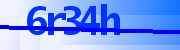

Step 2: Upscaled
Saved -> /content/debug_2_upscaled.png


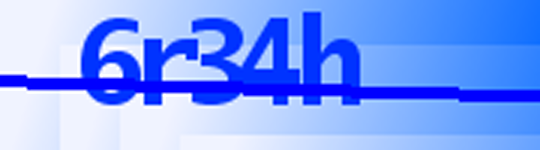

Step 3: Grayscale
Saved -> /content/debug_3_grayscale.png


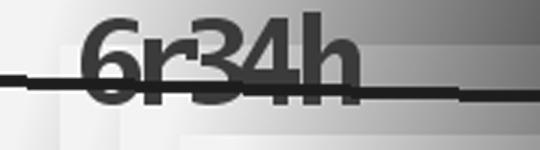

Step 4: Line Mask
Saved -> /content/debug_4_line_mask.png


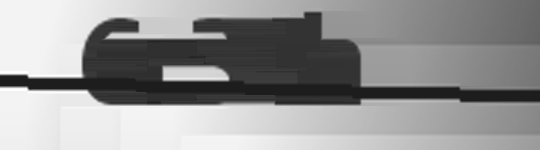

Step 5: Line Removed
Saved -> /content/debug_5_line_removed.png


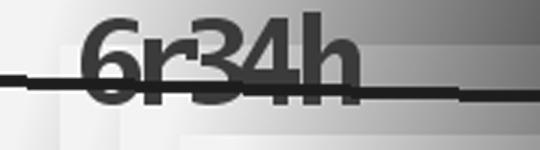

Step 6: Threshold
Saved -> /content/debug_6_threshold.png


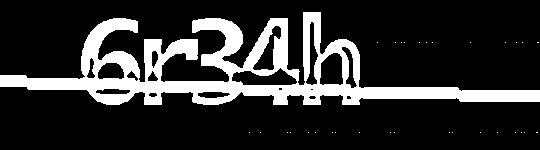

Step 7: Morphology Clean
Saved -> /content/debug_7_clean.png


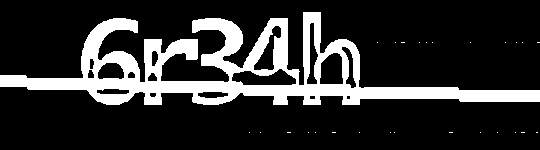

Saved -> /content/debug_8_ocr_ready.png


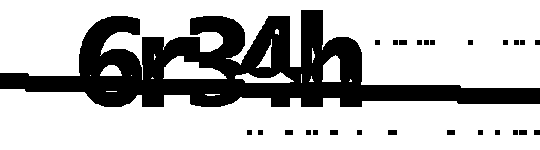


OCR RESULT:



In [ ]:

# ================================
# IMPORTS
# ================================
import cv2
import pytesseract
import numpy as np
from google.colab.patches import cv2_imshow

# ================================
# IMAGE PATH
# ================================
image_path = "/content/c3.png"

# ================================
# DEBUG FUNCTION
# ================================
def debug(img, name):
    path = f"/content/debug_{name}.png"
    cv2.imwrite(path, img)
    print(f"Saved -> {path}")
    cv2_imshow(img)

# ================================
# LOAD IMAGE
# ================================
img = cv2.imread(image_path)

print("Step 1: Original")
debug(img, "1_original")

# ================================
# STEP 2: UPSCALE (improves OCR)
# ================================
img = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

print("Step 2: Upscaled")
debug(img, "2_upscaled")

# ================================
# STEP 3: GRAYSCALE
# ================================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Step 3: Grayscale")
debug(gray, "3_grayscale")

# ================================
# STEP 4: DETECT VERY DARK PIXELS
# (this will capture the line)
# ================================
# Detect horizontal line
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50,1))
line_mask = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

print("Step 4: Line Mask")
debug(line_mask, "4_line_mask")

# Remove line
no_line = cv2.inpaint(gray, line_mask, 3, cv2.INPAINT_TELEA)

print("Step 5: Line Removed")
debug(no_line, "5_line_removed")

# ================================
# STEP 6: THRESHOLD TEXT
# ================================
thresh = cv2.adaptiveThreshold(
    no_line,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    10
)
print("Step 6: Threshold")
debug(thresh, "6_threshold")

# ================================
# STEP 7: CLEAN NOISE
# ================================
kernel = np.ones((3,3),np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)

print("Step 7: Morphology Clean")
debug(clean, "7_clean")


# thicken letters
dilated = cv2.dilate(clean, kernel, iterations=2)

# invert for tesseract
ocr_img = cv2.bitwise_not(dilated)

debug(ocr_img, "8_ocr_ready")


# ================================
# OCR
# ================================
config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

text = pytesseract.image_to_string(ocr_img, config=config)

print("\n===================")
print("OCR RESULT:")
print(text.strip())
print("===================")

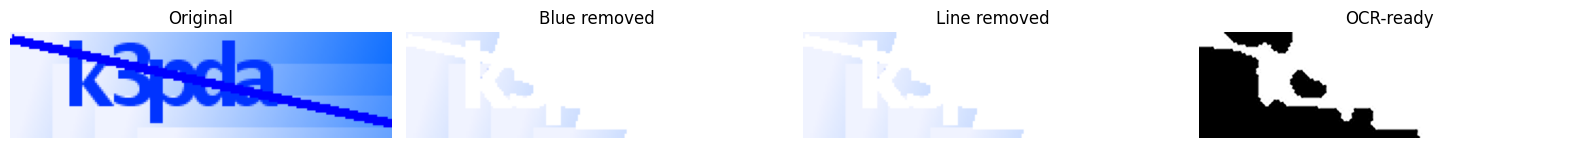


✅ OCR Result: 'ae'


In [ ]:
# ============================================================
#  CAPTCHA OCR — Google Colab ready
#  Handles: blue background removal + dark-line removal
# ============================================================

# ── 1. Install deps (run once in Colab) ─────────────────────
# !apt-get install -y tesseract-ocr
# !pip install pytesseract opencv-python-headless Pillow

import cv2
import numpy as np
import pytesseract
from PIL import Image
from google.colab.patches import cv2_imshow   # swap for cv2.imshow() locally
import matplotlib.pyplot as plt

# ── 2. Load image ────────────────────────────────────────────
def load_image(path: str) -> np.ndarray:
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not load: {path}")
    return img

# ── 3. Remove BLUE background ────────────────────────────────
def remove_blue_background(img_bgr: np.ndarray) -> np.ndarray:
    """
    Masks out pixels that are 'significantly blue':
    HSV hue ~100-130, reasonable saturation & value.
    Returns image with blue pixels turned white.
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Blue hue range in OpenCV  (0-179 scale)
    lower_blue = np.array([90,  50,  50])
    upper_blue = np.array([135, 255, 255])

    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Dilate mask slightly to catch anti-aliased blue edges
    kernel = np.ones((2, 2), np.uint8)
    blue_mask = cv2.dilate(blue_mask, kernel, iterations=1)

    result = img_bgr.copy()
    result[blue_mask > 0] = [255, 255, 255]   # replace blue → white
    return result

# ── 4. Remove DARK LINE (intensity-based) ────────────────────
def remove_dark_line(img_bgr: np.ndarray,
                     darkness_thresh: int = 60,
                     min_dark_run: int = 4) -> np.ndarray:
    """
    Removes the darkest pixels (black/near-black line) regardless
    of its position or angle.

    Strategy:
      • Convert to grayscale.
      • Any pixel with brightness < darkness_thresh AND part of a
        connected dark run (≥ min_dark_run neighbours) is treated
        as the line and inpainted white.

    darkness_thresh : 0-255 — pixels darker than this are candidates.
                      Lower = only catch truly black; raise if line is grey.
    min_dark_run    : discard isolated dark specks (noise) that aren't
                      part of a real line.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Threshold: keep only very dark pixels
    _, dark_mask = cv2.threshold(gray, darkness_thresh, 255, cv2.THRESH_BINARY_INV)

    # Remove tiny noise blobs — keep only line-sized dark regions
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        dark_mask, connectivity=8
    )

    line_mask = np.zeros_like(dark_mask)
    for label in range(1, num_labels):          # 0 = background
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_dark_run:                # ignore tiny specks
            line_mask[labels == label] = 255

    # Inpaint: fill line region using surrounding pixel colours
    # This preserves any text stroke that overlaps the line better
    result = cv2.inpaint(img_bgr, line_mask, inpaintRadius=3,
                         flags=cv2.INPAINT_TELEA)
    return result

# ── 5. Post-processing for OCR readability ──────────────────
def enhance_for_ocr(img_bgr: np.ndarray) -> np.ndarray:
    """
    Convert to grayscale → denoise → binarise → upscale.
    Returns a clean binary image ready for Tesseract.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Light denoise
    denoised = cv2.fastNlMeansDenoising(gray, h=10,
                                        templateWindowSize=7,
                                        searchWindowSize=21)

    # Otsu binarisation (auto threshold)
    _, binary = cv2.threshold(denoised, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Upscale 3× — Tesseract works best at ~300 DPI
    h, w = binary.shape
    upscaled = cv2.resize(binary, (w * 3, h * 3),
                          interpolation=cv2.INTER_CUBIC)

    # Slight sharpening after resize
    kernel = np.array([[0, -1,  0],
                       [-1, 5, -1],
                       [0, -1,  0]])
    sharpened = cv2.filter2D(upscaled, -1, kernel)

    return sharpened

# ── 6. Run Tesseract ─────────────────────────────────────────
def run_ocr(clean_img: np.ndarray) -> str:
    pil_img = Image.fromarray(clean_img)

    # PSM 8 = single word  |  whitelist keeps only expected chars
    config = (
        "--psm 8 "
        "--oem 3 "
        "-c tessedit_char_whitelist="
        "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789"
    )
    text = pytesseract.image_to_string(pil_img, config=config)
    return text.strip()

# ── 7. Debug visualiser ──────────────────────────────────────
def show_pipeline(original, no_blue, no_line, final):
    titles = ["Original", "Blue removed", "Line removed", "OCR-ready"]
    imgs   = [original, no_blue, no_line, final]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img, title in zip(axes, imgs, titles):
        if len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── 8. Main pipeline ─────────────────────────────────────────
def ocr_pipeline(image_path: str,
                 darkness_thresh: int = 60,
                 debug: bool = True) -> str:

    original   = load_image(image_path)
    no_blue    = remove_blue_background(original)
    no_line    = remove_dark_line(no_blue, darkness_thresh=darkness_thresh)
    ocr_ready  = enhance_for_ocr(no_line)

    if debug:
        show_pipeline(original, no_blue, no_line, ocr_ready)

    text = run_ocr(ocr_ready)
    print(f"\n✅ OCR Result: '{text}'")
    return text

# ── 9. Run it ────────────────────────────────────────────────
if __name__ == "__main__":
    # Upload your image in Colab first, then set the path:
    result = ocr_pipeline(
        image_path="/content/c1.png",
        darkness_thresh=60,   # ↑ raise (e.g. 80) if line is dark-grey not black
        debug=True
    )